# Any Function of Random Data is a Random Variable

And hence we can try to compute its mean and variance.

Let's illustrate this in the context of linear regression.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'y')

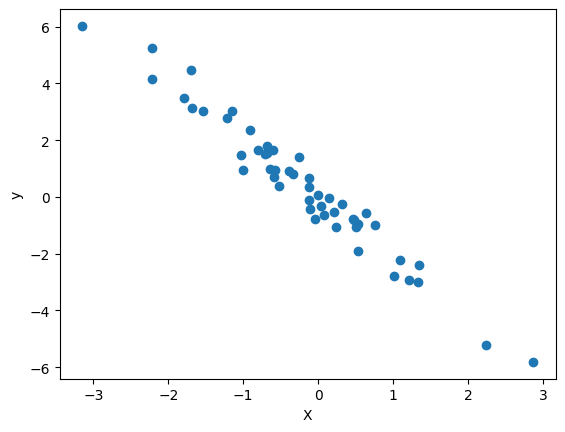

In [ ]:
# fix random seed
np.random.seed(12)

# generate random data
# linear relationship between X and y

N = 50 # number of points
epsilon = 0.5 # noise magnitude

X = np.random.randn(N)
y = -2*X + epsilon*np.random.randn(N)

# scatter plot of X and y
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# fit a model
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)

LinearRegression()

### What parameters did our model learn?

In [ ]:
# what are the weights of the linear regression?
print("This is the slope:", model.coef_)
print("This is the intercept:", model.intercept_)

This is the slope: [-2.0797619]
This is the intercept: -0.05318755884915094


### Why aren't they correct?

The true model is:
$$
y = -2*x + 0
$$
but we found:
$$
y = -1.9485*x + 0.0205
$$
**Why**?


## What if we repeat the experiment?

50 more points (from the same distribution, different random seed).

What will we see?

In [ ]:
# fix random seed
np.random.seed(0)

# generate random data
# linear relationship between X and y

N = 50 # number of points
epsilon = 0.5 # noise magnitude

X = np.random.randn(N)
y = -2*X + epsilon*np.random.randn(N)

# fit model and print slope and intercept
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)
print("This is the slope:", model.coef_)
print("This is the intercept:", model.intercept_)

This is the slope: [-2.02279549]
This is the intercept: -0.007267502655667668


### Anything that is a function of random data...

...is a random variable.

That means that it has a distribution, and in particular, a mean and varaince.

### Let's try to draw the PDF of the random variable

We will repeat the experiment $M=500$ times, and then plot a histogram of all the slopes we get.

In [ ]:
model.coef_[0]

np.float64(-2.022795493414758)

Text(0, 0.5, 'Frequency')

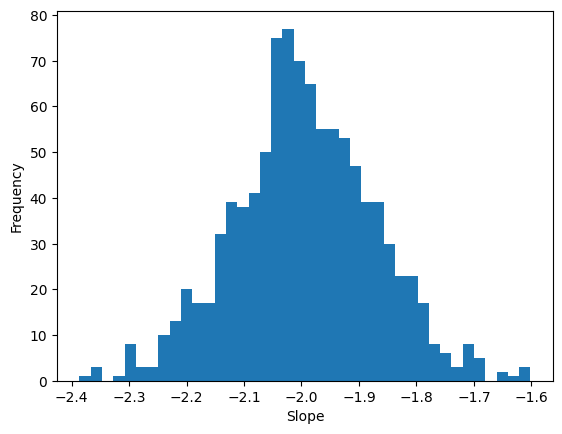

In [ ]:
M = 1000
N = 150
epsilon = 0.5 * 3
betas = np.zeros(M)

np.random.seed(0)
for a in range(M):
    # generate N data points, solve regression
    X = np.random.randn(N)
    y = -2*X + epsilon*np.random.randn(N)
    model = LinearRegression()
    model.fit(X.reshape(-1, 1), y)
    betas[a]=model.coef_[0]

# now plot a histogram of betas
plt.hist(betas, bins=40)
plt.xlabel('Slope')
plt.ylabel('Frequency')

In [ ]:
# standard dev of the betas
print("This is the standard dev of the slope:", np.std(betas))

This is the standard dev of the slope: 0.12326212445289127


## So if we know $N$ and $\epsilon$

...we can estimate the standard deviation of the slope.

What if we don't know $\epsilon$? (We know $N$).

In [ ]:
# estimate epsilon from the data
# fix random seed
np.random.seed(42)

# generate random data
# linear relationship between X and y

N = 150 # number of points
epsilon = 0.5 * 3

X = np.random.randn(N)
y = -2*X + epsilon*np.random.randn(N)

model = LinearRegression()
model.fit(X.reshape(-1, 1), y)
y_pred = model.predict(X.reshape(-1, 1))



In [ ]:
epsilon_pred = np.std(y - y_pred)*(N/(N-1))
print("This is the estimated value of epsilon:", epsilon_pred)

This is the estimated value of epsilon: 1.537267193918716


# Bootstrap Estimates

In [ ]:
def bootstrap_linreg_coef_std(X, y, B=1000, random_state=None):
    """
    Perform B bootstrap resamples of (X, y) to fit linear regressions
    and compute the standard deviation of the coefficients.

    Parameters:
    -----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix
    y : ndarray of shape (n_samples,)
        Target values
    B : int
        Number of bootstrap samples
    random_state : int or None
        Random seed (optional)

    Returns:
    --------

    coefs_std : ndarray of shape (n_features,)
        Standard deviation of coefficient estimates across the B bootstrap samples.
    """
    if random_state is not None:
        np.random.seed(random_state)

    n_samples = X.shape[0]
    n_features = X.shape[1]

    # Array to store coefficients from each bootstrap sample
    coefs = np.zeros((B, n_features))

    for i in range(B):
        # Generate random indices with replacement
        indices = np.random.choice(n_samples, size=n_samples, replace=True)

        # Create bootstrap sample
        X_boot = X[indices]
        y_boot = y[indices]

        # Fit linear regression on the bootstrap sample
        model = LinearRegression()
        model.fit(X_boot, y_boot)

        # Store the coefficients
        coefs[i, :] = model.coef_

    # Compute the standard deviation of the coefficients across all B samples
    coefs_std = np.std(coefs, axis=0)
    print("This is the standard dev of the slope:", coefs_std)
    return coefs

# Example usage:
# Suppose X is an (n x d) array of features, y is an (n,) array of targets
# coefs_std = bootstrap_linreg_coef_std(X, y, B=1000, random_state=42)
# print("Standard deviations of each coefficient:", coefs_std)


In [ ]:
beta_bs = bootstrap_linreg_coef_std(X.reshape(-1, 1), y, B=1000, random_state=45)

This is the standard dev of the slope: [0.1334107]
